In [ ]:
!hostnamectl

In [ ]:
# # Check JAX sees the GPU
# import jax
# print(jax.devices())  # should show CudaDevice(id=0)
# print(jax.default_backend())  # should show 'gpu'

# # Check CUDA version
# import subprocess
# print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

# # Check JAX/jaxlib versions
# import jaxlib
# print(f"JAX version: {jax.__version__}")
# print(f"jaxlib version: {jaxlib.__version__}")

# # Quick GPU computation test
# import jax.numpy as jnp
# x = jnp.ones((1000, 1000))
# print(f"Array device: {x.devices()}")  # should show CudaDevice

In [1]:
# tmp 
import os
tmp_dir = '/projects/bgdb/asachan/datasets/SKM_ageing_human/tmp'
os.environ["XLA_FLAGS"] = "--xla_gpu_force_compilation_parallelism=8"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Cache compiled kernels to disk (create this directory first)
cache_dir = os.path.join(tmp_dir, "asachan_jax_cache")
os.makedirs(cache_dir, exist_ok=True)
os.environ["JAX_COMPILATION_CACHE_DIR"] = cache_dir

In [2]:
import os
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

import moscot as mt
import moscot.plotting as mpl
from moscot.problems.time import TemporalProblem

In [3]:
import os
os.chdir("/projects/bgdb/asachan/methods/OT_FM")  # adjust path if needed
from utils import *

In [4]:
plt.rcParams["legend.scatterpoints"] = 1
sc.set_figure_params(scanpy=True, dpi=80, dpi_save=200)

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [5]:
rna_path = '/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_young_male.h5ad'
rna_path_filtered = '/projects/bgdb/asachan/datasets/SKM_ageing_human/filtered_all_cell_types.h5ad'

In [6]:
rna_adata = sc.read_h5ad(rna_path)
rna_adata

AnnData object with n_obs × n_vars = 3591 × 48355
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'percent.mt', 'age', 'tech', 'Sex', 'Country', 'age_pop', 'Annotation', 'age_sex', 'intervals_young'
    obsm: 'UMAP_1st', 'X_pca', 'X_pca_harmony', 'X_umap'

# MuSC to type1/2 transitions

In [ ]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['MuSC', 'Type II', 'Type I', 'Specialized MF'])].copy()

In [ ]:
rna_adata.obs['age_sex'] = (
    rna_adata.obs['age'].astype('float').astype(int).astype(str)
    + '_' + 
    rna_adata.obs['Sex'].astype(str)
)
rna_adata.obs['age_sex'].value_counts().sort_index()

In [ ]:
# Define interval mappings
interval_map = {
    # Male intervals
    '15_Male': 'interval_1_M',
    '18_Male': 'interval_1_M',
    '34_Male': 'interval_2_M',
    '38_Male': 'interval_2_M',
    '45_Male': 'interval_2_M',
    # Female intervals
    '17_Female': 'interval_1_F',
    '29_Female': 'interval_1_F',
    '34_Female': 'interval_2_F',
}

rna_adata.obs['intervals_young'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

# Verify
rna_adata.obs['intervals_young'].value_counts()

In [ ]:
# Define interval mappings
interval_map = {
    # Male intervals
    '77_Male': 'interval_1_M',
    '79_Male': 'interval_1_M',
    '82_Male': 'interval_1_M',
    '84_Male': 'interval_1_M',
    '85_Male': 'interval_2_M',
    '88_Male': 'interval_2_M',
    # Female intervals
    '79_Female': 'interval_1_F',
    '80_Female': 'interval_1_F',
    '82_Female': 'interval_1_F',
    '84_Female': 'interval_2_F',
    '89_Female': 'interval_2_F',
    '92_Female': 'interval_2_F',
    '99_Female': 'interval_2_F'
}

rna_adata.obs['intervals_old'] = rna_adata.obs['age_sex'].map(interval_map)
# unmapped values will be NaN — replace with 'other' or leave as NaN
# rna_adata.obs['age_sex_interval'] = rna_adata.obs['age_sex_interval'].fillna('other')

rna_adata.obs['intervals_old'].value_counts()

In [ ]:
mask = (
    # interval_1: MuSC only
    (rna_adata.obs['intervals_old'].isin(['interval_1_M', 'interval_1_F']) & 
     (rna_adata.obs['Annotation'] == 'MuSC'))
    |
    # interval_2: Type II, Type I, Specialized MF only (no MuSC)
    (rna_adata.obs['intervals_old'].isin(['interval_2_M', 'interval_2_F']) & 
     rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'Specialized MF']))
)

rna_adata = rna_adata[mask].copy()

# Verify — should show no MuSC in interval_2 and no other types in interval_1
rna_adata.obs.groupby(['intervals_old', 'Annotation']).size()

In [ ]:
n_cells_downsample = 2000
adatas = []

for interval, idx in rna_adata.obs.groupby('intervals_old').groups.items():
    subset = rna_adata[idx].copy()
    
    if interval.startswith('interval_2') and subset.shape[0] > n_cells_downsample:
        sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
    
    adatas.append(subset)

rna_adata = ad.concat(adatas)
del adatas

print(rna_adata.obs['intervals_old'].value_counts())

In [ ]:
# subset adata to male and female cells based on intervals_young
rna_adata_male = rna_adata[rna_adata.obs['intervals_old'].isin(['interval_1_M', 'interval_2_M'])].copy()
rna_adata_female = rna_adata[rna_adata.obs['intervals_old'].isin(['interval_1_F', 'interval_2_F'])].copy()

In [ ]:
rna_adata_female.obs

In [ ]:

import anndata as ad
ad.settings.allow_write_nullable_strings = True
# save
rna_adata_male.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_male.h5ad')
rna_adata_female.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/musc_transition_old_female.h5ad')

#### subset to young and old transitions (separately)

In [ ]:
#young_adata = rna_adata[rna_adata.obs['sample'] == 'YM3'].copy()
#old_adata = rna_adata[rna_adata.obs['sample'] == 'YM2'].copy()


In [ ]:
# subset to samples of interest
#rna_adata = rna_adata[rna_adata.obs['sample'].isin(['P26', 'YM2', 'OM6', 'OM9', 'P13', 'P5', 'OM5', 'OM7'])].copy()

In [ ]:
adata = rna_adata_female

In [ ]:
#subset to cell types of interest
rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II', 'Type I', 'MuSC', 'Specialized MF'])].copy()
#rna_adata = rna_adata[rna_adata.obs['Annotation'].isin(['Type II'])].copy()

#### Lower bound on number of cells per age

In [ ]:
# age_counts = rna_adata.obs['age'].value_counts()
# valid_ages = age_counts[age_counts >= 500].index

# rna_adata = rna_adata[rna_adata.obs['age'].isin(valid_ages)].copy()

# # # Verify
# print(rna_adata.obs['age'].value_counts())

#### Upper bound on number of cells per age

In [ ]:
# n_cells_downsample = 5000
# adatas = []

# for age, idx in rna_adata.obs.groupby('age').groups.items():
#     subset = rna_adata[idx].copy()
#     if subset.shape[0] > n_cells_downsample:
#         sc.pp.sample(subset, n=n_cells_downsample, copy=False, rng=42)
#     adatas.append(subset)

# rna_adata = ad.concat(adatas)
# del adatas

# # Verify
# print(rna_adata.obs['age'].value_counts())

In [ ]:
rna_adata.obs

In [ ]:
# #load adata with sub cluster labels
# type2_sub_cluster = sc.read_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/Myofiber_scsn_RNA.h5ad')
# type2_sub_cluster

In [ ]:
# type2_sub_cluster.obs['Annotation'].value_counts()

In [ ]:
# subset_adata = type2_sub_cluster[type2_sub_cluster.obs['Annotation'].isin(['Type II', 'ENOX1+ (II)', 'ID1+ (II)', 'SAA2+ (II)', 'DCLK1+ (II)', 'TNNT2+ (II)'])]

In [ ]:
# # save 
#rna_adata.write_h5ad('/projects/bgdb/asachan/datasets/SKM_ageing_human/type2_samples_oi.h5ad')

In [ ]:
display(rna_adata.obs['Annotation'].value_counts())
print(rna_adata.obs["Annotation"].unique())

## Instantiate OT

In [7]:
rna_adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_young
CELL6185_N1_1_2_1,YM1_Gluto3,2315.563120,1143,YM1,0.000058,15.0,snRNA,Male,China,young_pop,MuSC,15_Male,interval_1_M
CELL1256_N2_1_2_1,YM1_Gluto3,5242.880627,2251,YM1,1.036958,15.0,snRNA,Male,China,young_pop,MuSC,15_Male,interval_1_M
CELL3662_N1_1_1_2_1,YM1_Gluto1,4023.415859,1585,YM1,0.159944,15.0,snRNA,Male,China,young_pop,MuSC,15_Male,interval_1_M
CELL6033_N1_1_2_1,YM1_Gluto3,2417.205683,1051,YM1,0.151673,15.0,snRNA,Male,China,young_pop,MuSC,15_Male,interval_1_M
AGTAGTTACG_AGATTGCTCA_1_1_5_2,YM1_Gluteo_1,7472.000000,2354,YM1,11.790685,15.0,scRNA,Male,China,young_pop,MuSC,15_Male,interval_1_M
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL4002_N1_1_3_1,YM3_3,2702.066453,1161,YM3,0.000000,34.0,snRNA,Male,China,young_pop,Type I,34_Male,interval_2_M
CELL1043_N1_2_1_3_1,YM3_2,4494.199528,1560,YM3,0.011066,34.0,snRNA,Male,China,young_pop,Specialized MF,34_Male,interval_2_M
CELL1697_N1_1_1_1_2_10_1,P5_1,3353.583336,1283,P5,0.283609,45.0,snRNA,Male,Spain,young_pop,Type I,45_Male,interval_2_M
CELL782_N2_1_1_2_10_1,P5_3,3267.420451,1171,P5,0.110580,45.0,snRNA,Male,Spain,young_pop,Type I,45_Male,interval_2_M


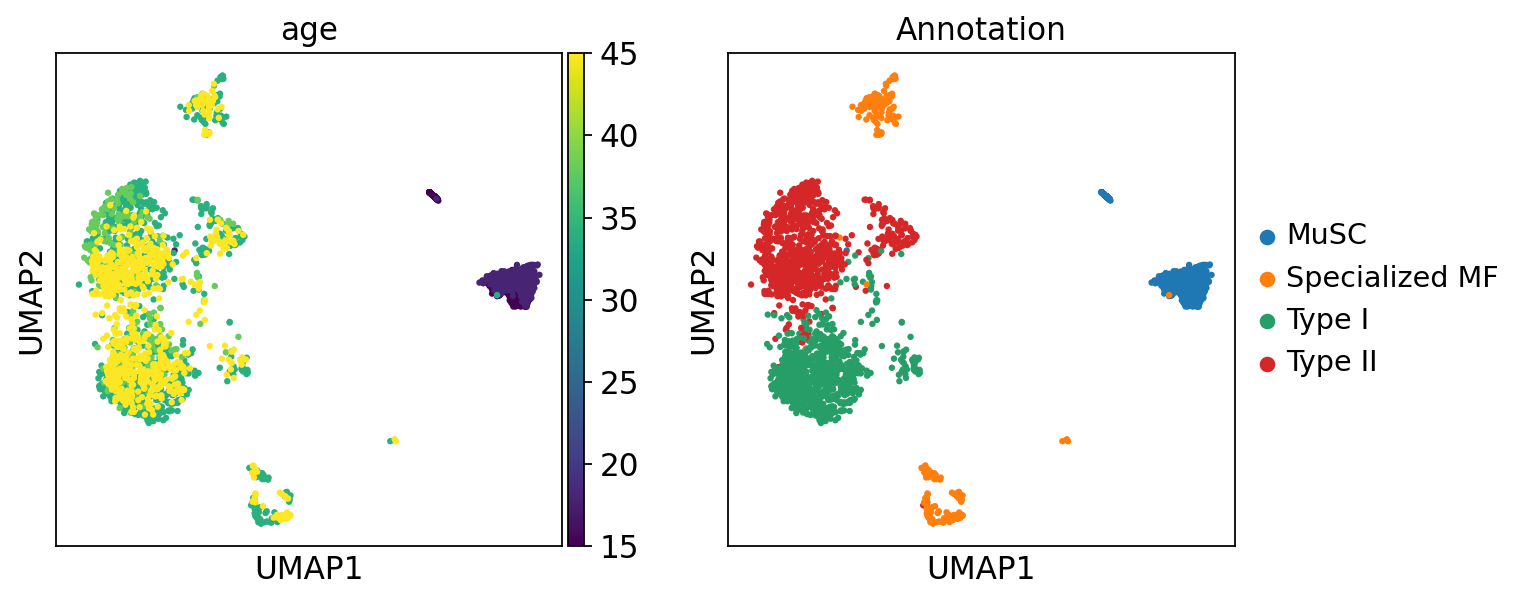

In [8]:
sc.pl.umap(rna_adata, color=['age', 'Annotation'])

In [9]:
# make temporal info numeric
def adapt_time(x):
    if x["intervals_young"] in ["interval_1_M"]:
        return 1.5
    if x["intervals_young"] in ["interval_2_M"]:
        return 3.5
    raise ValueError
    
rna_adata.obs["intervals_young"] = rna_adata.obs.apply(adapt_time, axis=1).astype("category")

In [10]:
# instantiate temporal OT problem
tp0 = TemporalProblem(rna_adata)
tp0 = tp0.prepare(time_key="intervals_young")

INFO     Computing pca with `n_comps=30` for `xy` using `adata.X`                                                  


In [11]:
import networkx as nx

batch_column = "intervals_young"
batch1, batch2 = 1.5, 3.5

indices = np.where(
    (rna_adata.obs[batch_column] == batch1) | (rna_adata.obs[batch_column] == batch2)
)[0]

adata_subset = rna_adata[indices]
sc.pp.neighbors(adata_subset, n_neighbors=30, use_rep="X_pca")

G = nx.from_numpy_array(adata_subset.obsp["connectivities"].todense())
assert nx.is_connected(G)

In [12]:
#if graph not connect check if there is a major disconnectivity due to batch effect in the latent space
n_components = nx.number_connected_components(G)
print(f"Number of connected components: {n_components}")
# Check sizes of each component
sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f"Component sizes: {sizes}")

Number of connected components: 1
Component sizes: [3591]


In [13]:
df = pd.DataFrame(
    index=adata_subset.obs_names,
    columns=adata_subset.obs_names,
    data=adata_subset.obsp["connectivities"].todense().astype("float"),
)

In [14]:
t1, t2 = 1.5, 3.5
prob = tp0[t1, t2]
expected = prob.adata_src.obs_names.append(prob.adata_tgt.obs_names)
Gdf = df.loc[expected, expected].astype(float)
prob.set_graph_xy(Gdf, t=100.0)

In [15]:
import scanpy as sc
sc.settings.verbosity = 3  # shows more detail
# epsilon: entropic regularization strength
#batch_size is for sinkhorn iterations, the grpah omputation and transfer to gpu (compilation) takes most time
tp0 = tp0.solve(epsilon=1e-3, scale_cost="mean", max_iterations=1e7) 

INFO     Solving `1` problems                                                                                      
INFO     Solving problem BirthDeathProblem[stage='prepared', shape=(1591, 2000)].                                  


W0316 04:57:20.063003  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:57:31.847721  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:57:32.453076  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:57:33.530733  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:57:33.719381  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:57:34.972692  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:57:37.239596  173034 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:57:37.240933  173033 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04

### Save objects after computation

In [16]:
import cloudpickle
with open(f'{tmp_dir}/musc_transition_young_male.pkl', 'wb') as f:
    cloudpickle.dump(tp0, f)
print("Saved!")

Saved!


In [17]:
import numpy as np
import scipy.sparse as sp

T_15_35 = tp0[1.5, 3.5].solution.transport_matrix

# JAX -> NumPy
T_15_35_np = np.asarray(T_15_35)

# NumPy -> sparse (CSR)
T_15_35_csr = sp.csr_matrix(T_15_35_np)

sp.save_npz(os.path.join(tmp_dir, "T_1.5_3.5_musc_transition_young_male.npz"), T_15_35_csr)

W0316 04:58:50.055695  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:58:50.080542  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:58:50.100869  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:58:50.156412  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:58:50.223723  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:58:50.264052  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:58:50.303838  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:58:50.344401  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.


## Visualize cell clusters of interest

In [18]:
rna_adata.obs["Annotation"] = rna_adata.obs["Annotation"].astype("category")
order_cell_types = rna_adata.obs["Annotation"].cat.categories.tolist()
order_cell_types

['MuSC', 'Specialized MF', 'Type I', 'Type II']

W0316 04:59:07.126708  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:07.176486  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:07.249470  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:07.288271  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:07.326033  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:07.366892  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:07.388864  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:07.429773  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04

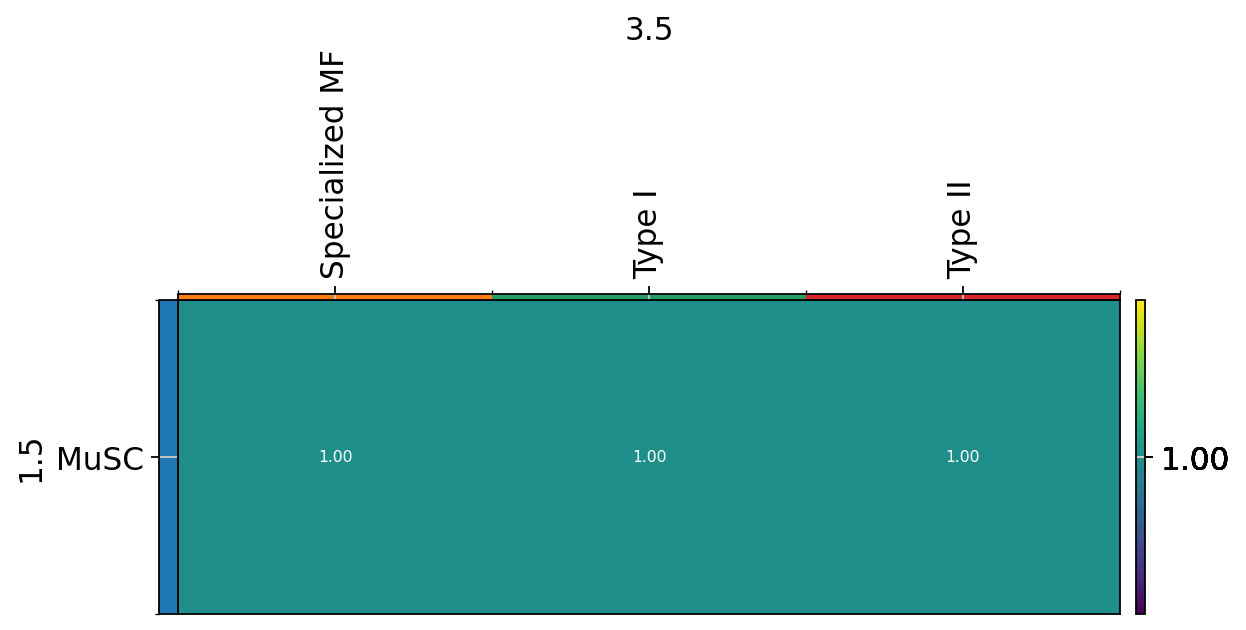

In [19]:
#aggregating the transport matrix by bins of interest
# ANSCESTORS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=False,
    key_added="transitions_1.5_3.5_large",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_large",
)
plt.tight_layout()
plt.show()

W0316 04:59:14.001816  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:14.028380  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:14.076699  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:14.124667  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:14.191872  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:14.232672  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:14.269166  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04:59:14.288359  170334 sol_gpu_cost_model.cc:102] No SoL config found for device: NVIDIA H200. Using default config.
W0316 04

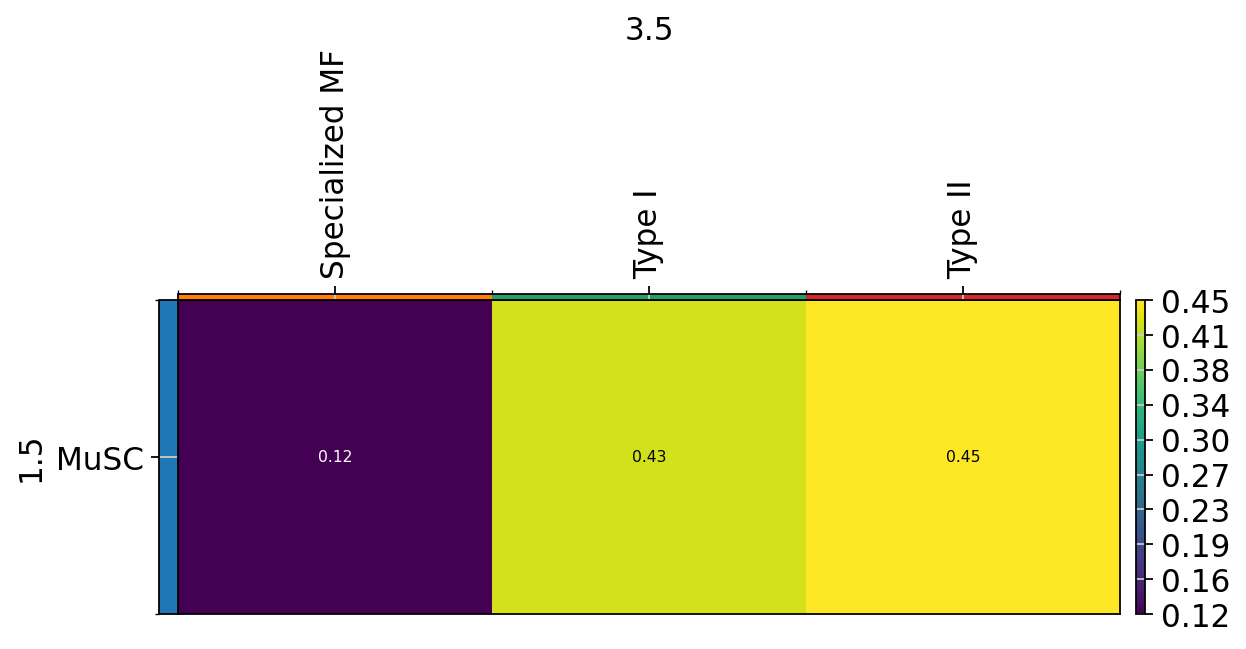

In [20]:
#aggregating the transport matrix by chronological age
# DESCENDANTS

ct_desc = tp0.cell_transition(
    1.5,
    3.5,
    {"Annotation": order_cell_types},
    {"Annotation": order_cell_types},
    forward=True,
    key_added="transitions_1.5_3.5_soi",
)

fig, ax = plt.subplots(figsize=(8, 6))
mpl.cell_transition(
    tp0,
    fontsize=7,
    figsize=(8, 6),
    return_fig=True,
    ax=ax,
    key="transitions_1.5_3.5_soi",
)
plt.tight_layout()
plt.show()

In [21]:
tp0.sankey(
    source=1.5,
    target=3.5,
    source_groups={"Annotation": order_cell_types},
    target_groups={"Annotation": order_cell_types},
    threshold=0.05,
    order_annotations=order_cell_types[::-1],
    normalize=True,
)

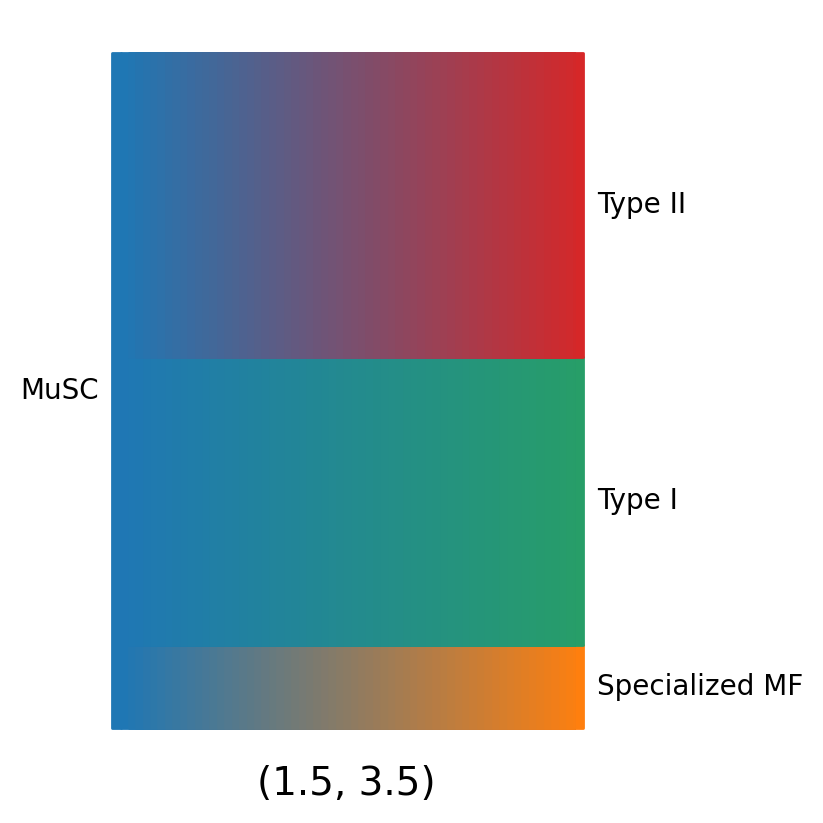

In [22]:
mpl.sankey(tp0, dpi=100, figsize=(4, 4), fontsize=10, interpolate_color=True)

## Identifying driver genes

In [23]:
X_orig = tp0.adata.X.copy()

#check mean and min and max of X
print(X_orig.mean(), X_orig.min(), X_orig.max())

0.046656553 0.0 8.498967


In [24]:
sc.pp.normalize_total(tp0.adata)
sc.pp.log1p(tp0.adata)

normalizing counts per cell
    finished (0:00:00)


In [25]:
tp0.adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,sample,percent.mt,age,tech,Sex,Country,age_pop,Annotation,age_sex,intervals_young
CELL6185_N1_1_2_1,YM1_Gluto3,2315.563120,1143,YM1,0.000058,15.0,snRNA,Male,China,young_pop,MuSC,15_Male,1.5
CELL1256_N2_1_2_1,YM1_Gluto3,5242.880627,2251,YM1,1.036958,15.0,snRNA,Male,China,young_pop,MuSC,15_Male,1.5
CELL3662_N1_1_1_2_1,YM1_Gluto1,4023.415859,1585,YM1,0.159944,15.0,snRNA,Male,China,young_pop,MuSC,15_Male,1.5
CELL6033_N1_1_2_1,YM1_Gluto3,2417.205683,1051,YM1,0.151673,15.0,snRNA,Male,China,young_pop,MuSC,15_Male,1.5
AGTAGTTACG_AGATTGCTCA_1_1_5_2,YM1_Gluteo_1,7472.000000,2354,YM1,11.790685,15.0,scRNA,Male,China,young_pop,MuSC,15_Male,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CELL4002_N1_1_3_1,YM3_3,2702.066453,1161,YM3,0.000000,34.0,snRNA,Male,China,young_pop,Type I,34_Male,3.5
CELL1043_N1_2_1_3_1,YM3_2,4494.199528,1560,YM3,0.011066,34.0,snRNA,Male,China,young_pop,Specialized MF,34_Male,3.5
CELL1697_N1_1_1_1_2_10_1,P5_1,3353.583336,1283,P5,0.283609,45.0,snRNA,Male,Spain,young_pop,Type I,45_Male,3.5
CELL782_N2_1_1_2_10_1,P5_3,3267.420451,1171,P5,0.110580,45.0,snRNA,Male,Spain,young_pop,Type I,45_Male,3.5


In [ ]:
# Get driver TFs for age-chronological_young/cell-cluster-2 (young) → age-chronological_old/cell-cluster-1 (old) transition
drivers_spec, top_pos, top_neg = driver_tfs_for_subset(
    tp=tp0,
    old_cell_cluster='Type II',
    young_cell_cluster='MuSC',
    cell_cluster_col='Annotation',
    timepoint_col='intervals_young',
    t_young=1.5,
    t_old=3.5,
)